In [5]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

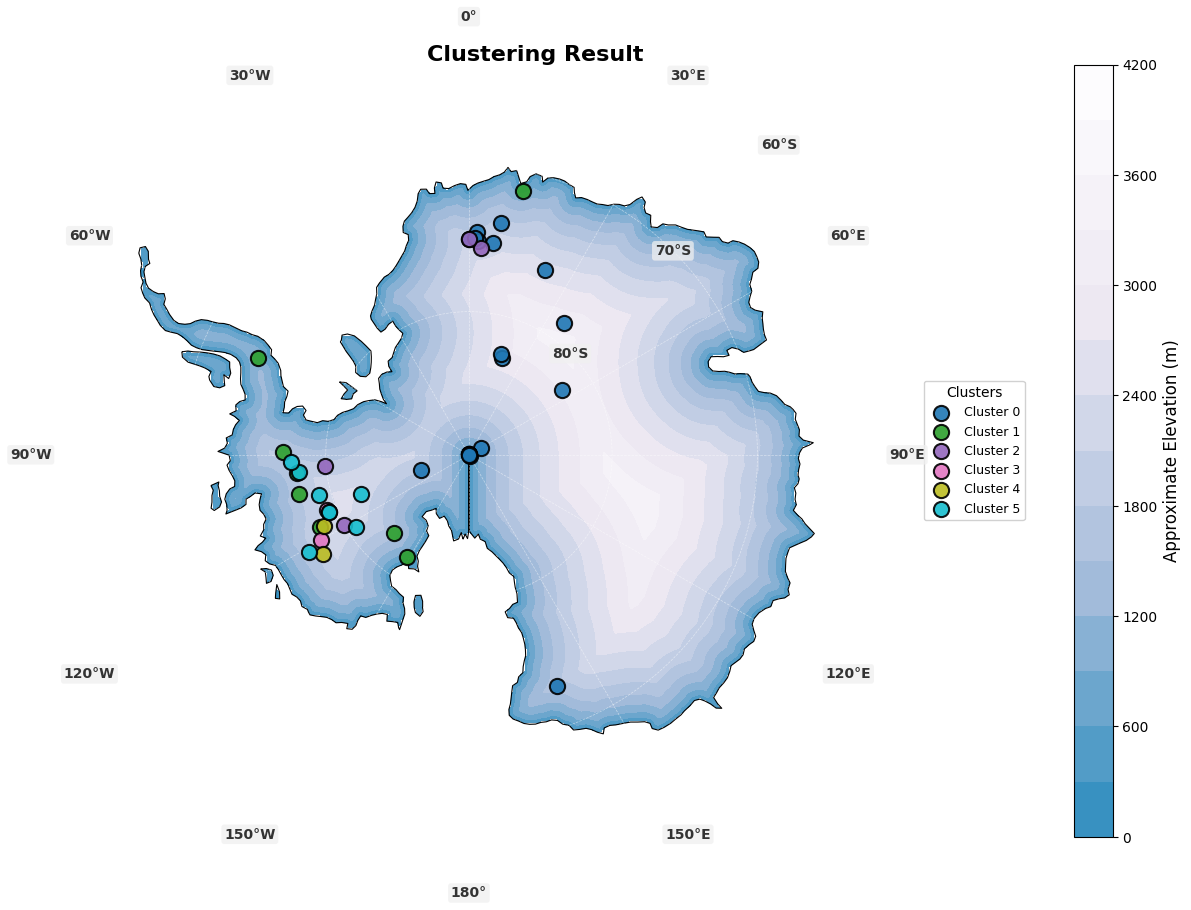

In [6]:
# 不强制画三个簇

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
from shapely.geometry import Point, LineString
import warnings

warnings.filterwarnings("ignore")


# =========================
# 1. 读取数据
# =========================

df_cluster = pd.read_csv(PROJECT_ROOT/"cluster/chem/chem_cluster.csv")

# 第一列统一改成 site
df_cluster.rename(columns={df_cluster.columns[0]: "site"}, inplace=True)

# 如果 lon / lat 是字符串，先转成 float
df_cluster["lon"] = (
    df_cluster["lon"]
    .astype(str)
    .str.replace("−", "-", regex=False)
    .astype(float)
)

df_cluster["lat"] = (
    df_cluster["lat"]
    .astype(str)
    .str.replace("−", "-", regex=False)
    .astype(float)
)

# 删除缺少坐标或聚类标签的行
df_merged = df_cluster.dropna(subset=["lon", "lat", "Level_0"]).copy()

# 聚类标签转成整数，避免 0.0 / 1.0 这种显示
df_merged["Level_0"] = df_merged["Level_0"].astype(int)


# =========================
# 2. 绘图函数
# =========================

def plot_clusters_map(
    df,
    cluster_col="Level_0",
    out_filename=None,
    title="Clustering Result"
):
    # -------------------------
    # 坐标转换：经纬度 -> 南极极地投影
    # -------------------------
    points = [Point(lon, lat) for lon, lat in zip(df["lon"], df["lat"])]

    gdf_sites = gpd.GeoDataFrame(
        df,
        geometry=points,
        crs="EPSG:4326"
    ).to_crs(epsg=3031)

    # -------------------------
    # 加载南极大陆底图
    # -------------------------
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)
    ata_gdf = world[world["NAME"] == "Antarctica"].to_crs(epsg=3031)

    ata_union = ata_gdf.unary_union
    ata_boundary = ata_union.boundary
    minx, miny, maxx, maxy = ata_union.bounds

    # -------------------------
    # 模拟海拔背景
    # -------------------------
    x = np.linspace(minx, maxx, 300)
    y = np.linspace(miny, maxy, 300)
    xx, yy = np.meshgrid(x, y)

    pts = gpd.GeoSeries(
        [Point(px, py) for px, py in zip(xx.flatten(), yy.flatten())],
        crs="EPSG:3031"
    )

    inside = pts.within(ata_union)

    dist = np.zeros(len(pts))
    dist[inside] = pts[inside].distance(ata_boundary)

    elev = 3.26 * np.sqrt(dist)
    elev_grid = elev.reshape(xx.shape)
    elev_grid[~inside.values.reshape(xx.shape)] = np.nan

    colors = ["#2b8cbe", "#a6bddb", "#ece7f2", "#ffffff"]
    cmap_elev = mcolors.LinearSegmentedColormap.from_list(
        "ice_elev_strong",
        colors
    )

    # -------------------------
    # 经纬度网格线
    # -------------------------
    lats_to_plot = [-80, -70, -60]
    lons_to_plot = np.arange(-180, 180, 30)

    lat_lines = [
        LineString([(lon, lat) for lon in np.linspace(-180, 180, 360)])
        for lat in lats_to_plot
    ]

    lon_lines = [
        LineString([(lon, -90), (lon, -55)])
        for lon in lons_to_plot
    ]

    graticule = gpd.GeoDataFrame(
        geometry=lat_lines + lon_lines,
        crs="EPSG:4326"
    ).to_crs(epsg=3031)

    def draw_graticule_and_labels(ax):
        graticule.plot(
            ax=ax,
            color="white",
            linewidth=0.5,
            linestyle="--",
            alpha=0.5,
            zorder=3
        )

        text_kwargs = {
            "color": "#333333",
            "ha": "center",
            "va": "center",
            "fontsize": 10,
            "fontweight": "bold",
            "zorder": 10,
            "bbox": dict(
                facecolor="#f0f0f0",
                edgecolor="none",
                alpha=0.75,
                boxstyle="round,pad=0.2"
            )
        }

        # 标注经度
        for lon in np.arange(-180, 180, 30):
            pt = gpd.GeoSeries(
                [Point(lon, -60)],
                crs="EPSG:4326"
            ).to_crs(epsg=3031).iloc[0]

            if lon == 0:
                label_text = "0°"
            elif lon == -180:
                label_text = "180°"
            else:
                label_text = f"{abs(lon)}°{'E' if lon > 0 else 'W'}"

            ax.text(pt.x, pt.y, label_text, **text_kwargs)

        # 标注纬度
        for lat in lats_to_plot:
            pt = gpd.GeoSeries(
                [Point(45, lat)],
                crs="EPSG:4326"
            ).to_crs(epsg=3031).iloc[0]

            ax.text(pt.x, pt.y, f"{abs(lat)}°S", **text_kwargs)

    # =========================
    # 3. 开始绘图
    # =========================

    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_facecolor("#08306b")

    padding = 750000
    ax.set_xlim(minx - padding, maxx + padding * 2.2)
    ax.set_ylim(miny - padding, maxy + padding)

    # 背景
    cf = ax.contourf(
        xx,
        yy,
        elev_grid,
        levels=np.linspace(0, 4200, 15),
        cmap=cmap_elev,
        alpha=1.0,
        zorder=1
    )

    ata_gdf.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        zorder=2
    )

    draw_graticule_and_labels(ax)

    cbar = plt.colorbar(cf, ax=ax, fraction=0.036, pad=0.04)
    cbar.set_label("Approximate Elevation (m)", fontsize=12)

    # =========================
    # 4. 自动读取实际存在的簇
    # =========================

    cluster_ids = sorted(gdf_sites[cluster_col].dropna().unique())

    # 自动生成颜色：簇少用 tab10，簇多用 tab20
    if len(cluster_ids) <= 10:
        cmap_cluster = cm.get_cmap("tab10", len(cluster_ids))
    else:
        cmap_cluster = cm.get_cmap("tab20", len(cluster_ids))

    for i, c in enumerate(cluster_ids):
        c_data = gdf_sites[gdf_sites[cluster_col] == c]

        if c_data.empty:
            continue

        ax.scatter(
            c_data.geometry.x,
            c_data.geometry.y,
            color=cmap_cluster(i),
            label=f"Cluster {c}",
            s=120,
            edgecolors="black",
            linewidth=1.5,
            zorder=5,
            alpha=0.9
        )

    # 图例
    ax.legend(
        loc="center right",
        title="Clusters",
        framealpha=0.9,
        fontsize=9
    )

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()

    if out_filename is not None:
        plt.savefig(out_filename, dpi=300, bbox_inches="tight")

    plt.show()


# =========================
# 5. 执行绘图
# =========================

plot_clusters_map(
    df_merged,
    cluster_col="Level_0",
    out_filename="plot_clusters_auto.png",
    title="Clustering Result"
)

实际绘制的簇: [0, 1, 2, 3, 4, 5]
匹配到的站点数: 43
accum_100y 中总站点数: 43
accum_100y 中没有匹配到 cluster 的站点数: 0
cluster 中没有匹配到 accum_100y 的站点数: 0
Global y range: 20.944 55351.31137


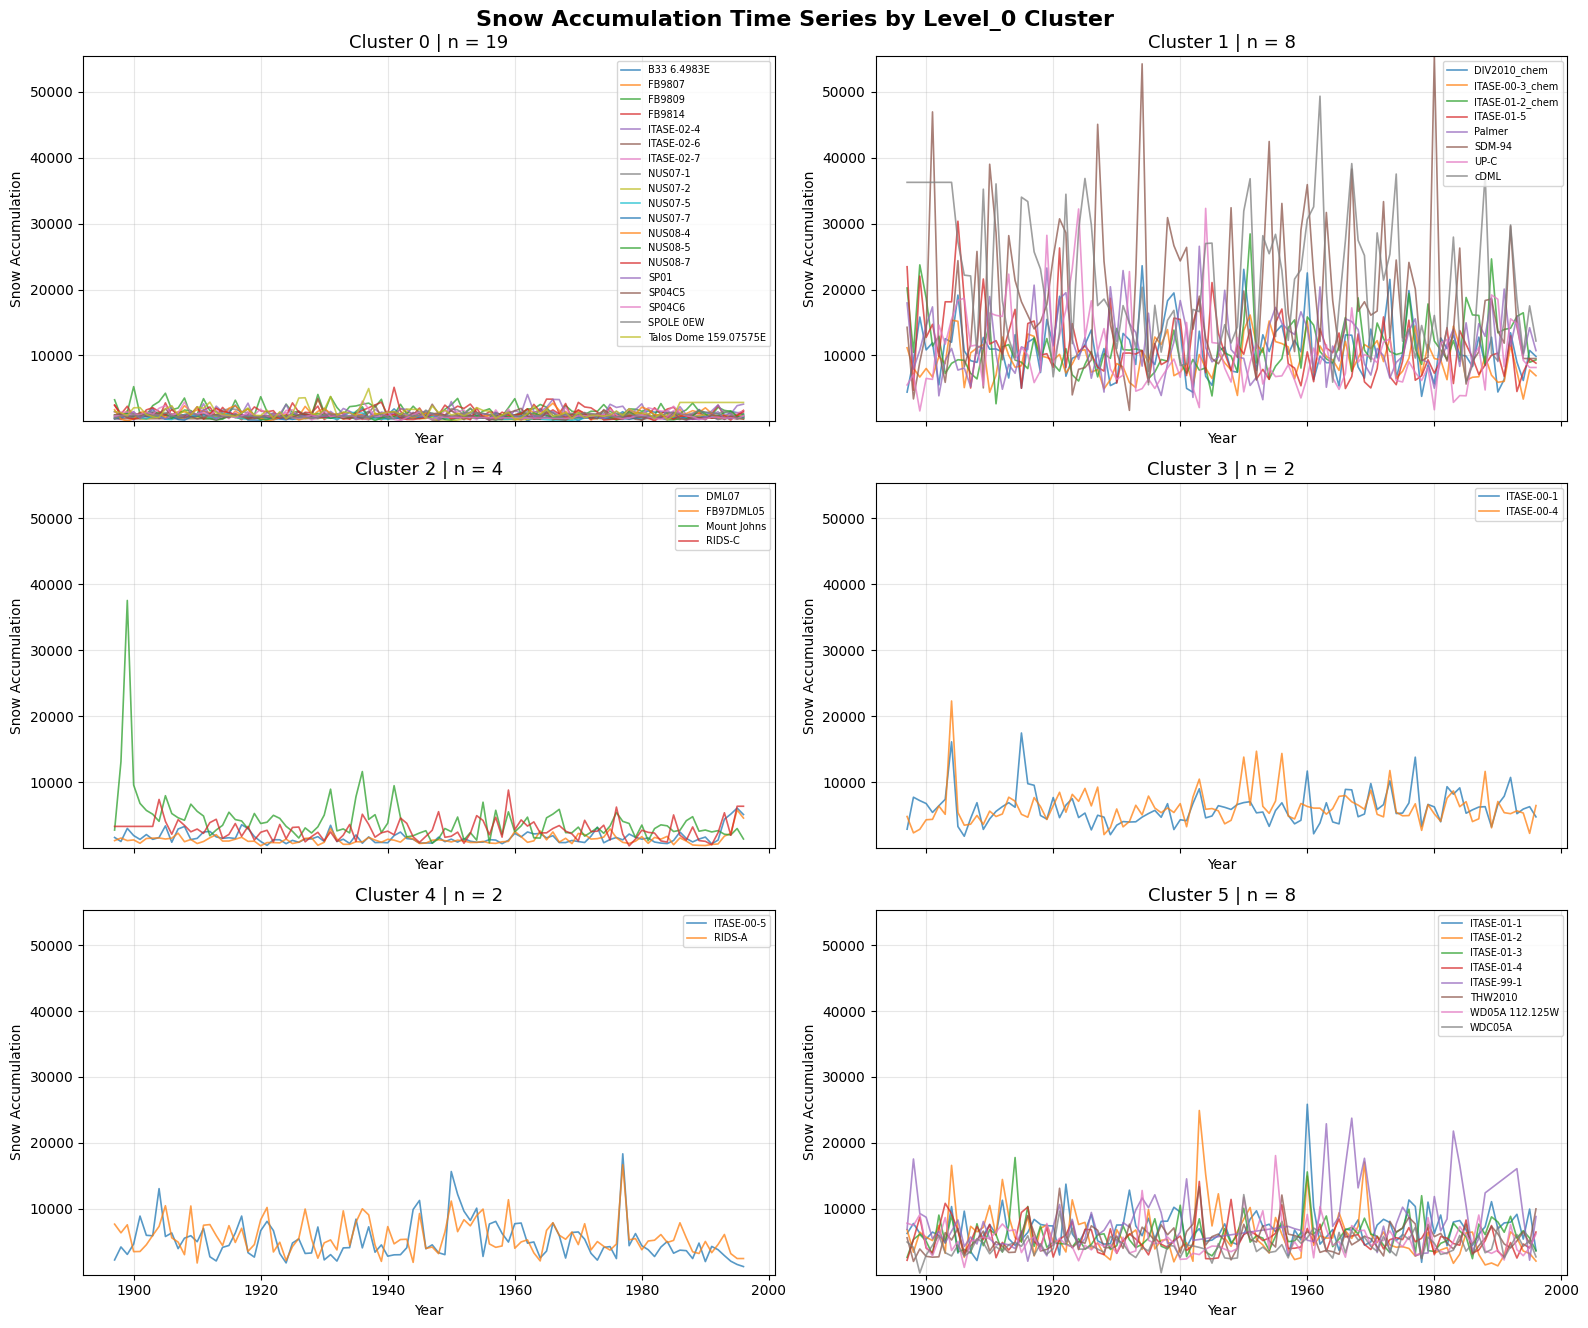

In [4]:
# 判断cluster合并思路

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# =========================
# 1. 读取数据
# =========================

accum_path = "/sharedata/home/cyyang/SEMPO_copy/dataset/icecore/chem/chem.csv"
cluster_path = "/sharedata/home/cyyang/SEMPO_copy/cluster/chem/chem_cluster.csv"

df_accum = pd.read_csv(accum_path)
df_cluster = pd.read_csv(cluster_path)

# cluster 文件第一列是站点名
df_cluster = df_cluster.rename(columns={df_cluster.columns[0]: "site"})

# 去掉站点名前后空格，避免 B31 3.43W 这种列名带空格导致匹配不上
df_cluster["site_clean"] = df_cluster["site"].astype(str).str.strip()

# accum 里的列名也做一个映射
year_col = df_accum.columns[0]
site_cols = df_accum.columns[1:]

site_col_map = {
    col.strip(): col
    for col in site_cols
}

# =========================
# 2. 转换数值
# =========================

df_accum[year_col] = pd.to_numeric(df_accum[year_col], errors="coerce")

for col in site_cols:
    df_accum[col] = pd.to_numeric(df_accum[col], errors="coerce")

# =========================
# 3. 按 Level_0 分组
# =========================

cluster_col = "Level_0"

# 只保留 accum_100y 里确实存在的站点
df_cluster_matched = df_cluster[
    df_cluster["site_clean"].isin(site_col_map.keys())
].copy()

# Level_0 转成 int，方便排序和显示
df_cluster_matched[cluster_col] = df_cluster_matched[cluster_col].astype(int)

clusters = sorted(df_cluster_matched[cluster_col].dropna().unique())

print("实际绘制的簇:", clusters)
print("匹配到的站点数:", len(df_cluster_matched))
print("accum_100y 中总站点数:", len(site_cols))

# 如果有没匹配上的站点，打印出来检查
unmatched_accum_sites = sorted(set(site_col_map.keys()) - set(df_cluster["site_clean"]))
unmatched_cluster_sites = sorted(set(df_cluster["site_clean"]) - set(site_col_map.keys()))

print("accum_100y 中没有匹配到 cluster 的站点数:", len(unmatched_accum_sites))
if unmatched_accum_sites:
    print(unmatched_accum_sites)

print("cluster 中没有匹配到 accum_100y 的站点数:", len(unmatched_cluster_sites))
if unmatched_cluster_sites:
    print(unmatched_cluster_sites)

# =========================
# 4. 画图：有几个 Level_0 簇就画几个子图
# =========================


matched_site_cols = [
    site_col_map[s]
    for s in df_cluster_matched["site_clean"]
    if s in site_col_map
]

global_min = df_accum[matched_site_cols].min().min()
global_max = df_accum[matched_site_cols].max().max()

print("Global y range:", global_min, global_max)

n_clusters = len(clusters)

# 自动安排子图布局
ncols = 2 if n_clusters > 1 else 1
nrows = math.ceil(n_clusters / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(8 * ncols, 4.5 * nrows),
    sharex=True
)

# 保证 axes 是一维数组，方便循环
if n_clusters == 1:
    axes = np.array([axes])
else:
    axes = np.array(axes).reshape(-1)

years = df_accum[year_col]

for ax, cluster_id in zip(axes, clusters):
    cluster_sites_clean = df_cluster_matched.loc[
        df_cluster_matched[cluster_col] == cluster_id,
        "site_clean"
    ].tolist()

    # clean name 转回 accum_100y 里的原始列名
    cluster_site_cols = [
        site_col_map[s]
        for s in cluster_sites_clean
        if s in site_col_map
    ]

    for site_col in cluster_site_cols:
        ax.plot(
            years,
            df_accum[site_col],
            linewidth=1.2,
            alpha=0.75,
            label=site_col.strip()
        )

    ax.set_title(f"Cluster {cluster_id} | n = {len(cluster_site_cols)}", fontsize=13)
    ax.set_xlabel("Year")
    ax.set_ylabel("Snow Accumulation")
    ax.set_ylim(global_min, global_max)
    ax.grid(alpha=0.3)

    # 站点太多时，legend 会很挤，所以放小一点
    ax.legend(
        fontsize=7,
        loc="best",
        framealpha=0.8
    )

# 多出来的空子图删掉
for j in range(n_clusters, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Snow Accumulation Time Series by Level_0 Cluster",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [11]:

# chem合并/重构类

import pandas as pd

def reassign_cluster(level_0):
    if pd.isna(level_0):
        return np.nan
    if level_0 in [0,2]:
        return 1
    elif level_0 in [5,3,4]:
        return 0
    elif level_0 in [1]:
        return 2
    else:
        return np.nan
    
df_cluster = pd.read_csv(PROJECT_ROOT/'cluster/chem/chem_cluster.csv')
df_cluster.rename(columns={df_cluster.columns[0]: 'site'}, inplace=True)   
df_cluster['Level_0'] = df_cluster['Level_0'].apply(reassign_cluster)
df_cluster.drop('Level_1', axis=1, inplace=True)
df_cluster.to_csv(PROJECT_ROOT/"cluster/chem/chem_cluster_mapped.csv", index=False)


In [ ]:

# accum_100y合并/重构类

import pandas as pd

def reassign_cluster(level_0):
    if pd.isna(level_0):
        return np.nan
    if level_0 in [0,1,3]:
        return 1
    elif level_0 in [2,6]:
        return 0
    elif level_0 in [4,5]:
        return 2
    else:
        return np.nan
    
df_cluster = pd.read_csv('/sharedata/home/cyyang/SEMPO/cluster/accum/accum_100y_cluster.csv')
df_cluster.rename(columns={df_cluster.columns[0]: 'site'}, inplace=True)   
df_cluster['Level_0'] = df_cluster['Level_0'].apply(reassign_cluster)
df_cluster.drop('Level_1', axis=1, inplace=True)
df_cluster.to_csv("/sharedata/home/cyyang/SEMPO/cluster/accum/accum_100y_cluster_mapped.csv", index=False)


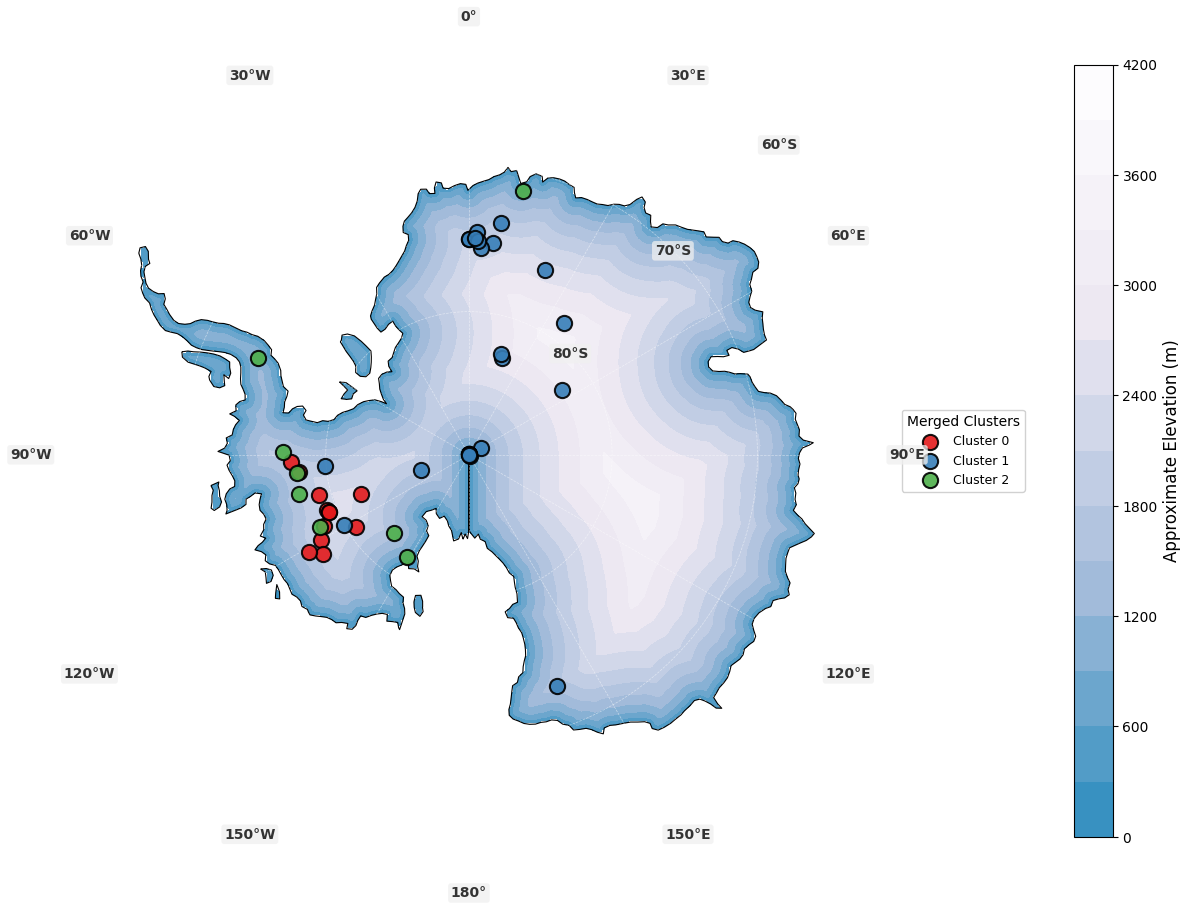

In [12]:
# 三类 颜色固定
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import fiona
from shapely.geometry import shape, Point, LineString
import warnings

warnings.filterwarnings('ignore')

# # 1. 加载数据
df_sources = pd.read_csv(PROJECT_ROOT/'dataset/icecore/data_sources.csv')
df_cluster = pd.read_csv(PROJECT_ROOT/'cluster/chem/chem_cluster_mapped.csv')
df_cluster.rename(columns={df_cluster.columns[0]: 'site'}, inplace=True)

# 2. 合并数据并创建新的聚类标签（05→0, 123→1, 46→2）
df_merged = df_cluster

def reassign_cluster(level_0):
    if pd.isna(level_0):
        return np.nan
    if level_0 in [0, 5]:
        return 0
    elif level_0 in [1, 2, 3]:
        return 1
    elif level_0 in [4, 6]:
        return 2
    else:
        return np.nan

# df_merged['Cluster_New'] = df_merged['Level_0'].apply(reassign_cluster)

# 3. 核心绘图函数
def plot_merged_clusters_map(df, out_filename, title):
    # 清理坐标数据
    # df = df.dropna(subset=['Latitude', 'Longitude', 'Cluster_New']).copy()
    # df['lon'] = df['Longitude'].astype(str).str.replace('−', '-').astype(float)
    # df['lat'] = df['Latitude'].astype(str).str.replace('−', '-').astype(float)

    # 转换为南极极地投影 (EPSG:3031)
    points = [Point(lon, lat) for lon, lat in zip(df['lon'], df['lat'])]
    gdf_sites = gpd.GeoDataFrame(df, geometry=points, crs="EPSG:4326").to_crs(epsg=3031)

    # 加载南极大陆底板
    url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    world = gpd.read_file(url)
    ata_gdf = world[world['NAME'] == 'Antarctica'].to_crs(epsg=3031)

    # 生成模拟海拔网格
    ata_union = ata_gdf.unary_union
    ata_boundary = ata_union.boundary
    minx, miny, maxx, maxy = ata_union.bounds

    x = np.linspace(minx, maxx, 300)
    y = np.linspace(miny, maxy, 300)
    xx, yy = np.meshgrid(x, y)
    pts = gpd.GeoSeries([Point(px, py) for px, py in zip(xx.flatten(), yy.flatten())], crs="EPSG:3031")

    inside = pts.within(ata_union)
    dist = np.zeros(len(pts))
    dist[inside] = pts[inside].distance(ata_boundary)
    elev = 3.26 * np.sqrt(dist)
    elev_grid = elev.reshape(xx.shape)
    elev_grid[~inside.values.reshape(xx.shape)] = np.nan

    # 海拔颜色表
    colors = ["#2b8cbe", "#a6bddb", "#ece7f2", "#ffffff"]
    cmap_elev = mcolors.LinearSegmentedColormap.from_list("ice_elev_strong", colors)

    # 经纬度网格
    lats_to_plot = [-80, -70, -60]
    lons_to_plot = np.arange(-180, 180, 30)

    lat_lines = [LineString([(lon, lat) for lon in np.linspace(-180, 180, 360)]) for lat in lats_to_plot]
    lon_lines = [LineString([(lon, -90), (lon, -55)]) for lon in lons_to_plot]
    graticule = gpd.GeoDataFrame(geometry=lat_lines + lon_lines, crs="EPSG:4326").to_crs(epsg=3031)

    def draw_graticule_and_labels(ax):
        graticule.plot(ax=ax, color='white', linewidth=0.5, linestyle='--', alpha=0.5, zorder=3)
        text_kwargs = {
            'color': '#333333', 'ha': 'center', 'va': 'center', 'fontsize': 10,
            'fontweight': 'bold', 'zorder': 10,
            'bbox': dict(facecolor='#f0f0f0', edgecolor='none', alpha=0.75, boxstyle='round,pad=0.2')
        }
        # 标注经度（南纬60°圆环）
        for lon in np.arange(-180, 180, 30):
            pt = gpd.GeoSeries([Point(lon, -60)], crs="EPSG:4326").to_crs(epsg=3031).iloc[0]
            label_text = f"{abs(lon)}°{'E' if lon > 0 else 'W' if lon < 0 else ''}"
            if lon == 0: label_text = "0°"
            if lon == -180: label_text = "180°"
            ax.text(pt.x, pt.y, label_text, **text_kwargs)
        # 标注纬度（东经45°射线）
        for lat in lats_to_plot:
            pt = gpd.GeoSeries([Point(45, lat)], crs="EPSG:4326").to_crs(epsg=3031).iloc[0]
            ax.text(pt.x, pt.y, f"{abs(lat)}°S", **text_kwargs)

    # 组装主图
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.set_facecolor('#08306b')
    padding = 750000
    ax.set_xlim(minx - padding, maxx + padding * 2.2)
    ax.set_ylim(miny - padding, maxy + padding)

    # 绘制海拔背景与大陆边界
    cf = ax.contourf(xx, yy, elev_grid, levels=np.linspace(0, 4200, 15), cmap=cmap_elev, alpha=1.0, zorder=1)
    ata_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8, zorder=2)
    draw_graticule_and_labels(ax)

    # 海拔 Colorbar
    cbar = plt.colorbar(cf, ax=ax, fraction=0.036, pad=0.04)
    cbar.set_label('Approximate Elevation (m)', fontsize=12)

    # 绘制三个新聚类（固定三色方案）
    cluster_colors = {
        0: '#e41a1c',
        1: '#377eb8',
        2: '#4daf4a'
    }
    cluster_labels = {
        0: 'Cluster 0',
        1: 'Cluster 1',
        2: 'Cluster 2'
    }

    for c in [0, 1, 2]:
        c_data = gdf_sites[gdf_sites['Level_0'] == c]
        if not c_data.empty:
            ax.scatter(c_data.geometry.x, c_data.geometry.y, 
                       color=cluster_colors[c], label=cluster_labels[c],
                       s=120, edgecolors='black', linewidth=1.5, zorder=5, alpha=0.9)

    # 图例设置
    ax.legend(loc='center right', title="Merged Clusters", framealpha=0.9, fontsize=9)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# 4. 执行绘图
plot_merged_clusters_map(df_merged, "plot_merged_clusters_level0.png", "Merged Clustering (05|123|46)")